In [2]:
import importlib
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

import db_config

from db_config import get_database_url, get_database_render_url
from sqlalchemy import create_engine

In [10]:
pd.set_option('display.float_format', '{:.3f}'.format)

In [87]:
engine_local = create_engine(get_database_url(), pool_pre_ping=True)
df = pd.read_sql(
    "SELECT * FROM public.pollen_by_date_time",
    engine_local
)

df.head()

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-17,04:00:00,4,2026-07-17,0.000,0.000,24.402,1.005,0.000,0.000,25.407
1,2026-07-17,04:00:00,5,2026-07-17,0.000,0.000,24.140,0.357,0.000,0.000,24.497
2,2026-07-17,09:00:00,1,2026-07-17,0.000,0.000,14.555,1.040,0.000,0.000,15.596
3,2026-07-17,09:00:00,2,2026-07-17,0.000,0.000,15.907,1.489,0.000,0.000,17.397
4,2026-07-17,09:00:00,3,2026-07-17,0.000,0.000,14.919,1.735,0.000,0.000,16.655


In [88]:
df['fdate'] = pd.to_datetime(df['fdate'], format='%Y-%m-%d')
df['ftime'] = pd.to_datetime(df['ftime'], format='%H:%M:%S').dt.time
df['analysis_time'] = pd.to_datetime(df['analysis_time'], format='%Y-%m-%d')
df.head(24)

,fdate,ftime,camps_point_id,analysis_time,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
0,2026-07-17,04:00:00,4,2026-07-17,0.000,0.000,24.402,1.005,0.000,0.000,25.407
1,2026-07-17,04:00:00,5,2026-07-17,0.000,0.000,24.140,0.357,0.000,0.000,24.497
2,2026-07-17,09:00:00,1,2026-07-17,0.000,0.000,14.555,1.040,0.000,0.000,15.596
3,2026-07-17,09:00:00,2,2026-07-17,0.000,0.000,15.907,1.489,0.000,0.000,17.397
4,2026-07-17,09:00:00,3,2026-07-17,0.000,0.000,14.919,1.735,0.000,0.000,16.655
5,2026-07-17,09:00:00,4,2026-07-17,0.000,0.000,15.973,1.210,0.000,0.000,17.184
6,2026-07-17,09:00:00,5,2026-07-17,0.000,0.000,18.803,0.593,0.000,0.000,19.396
7,2026-07-17,09:00:00,6,2026-07-17,0.000,0.000,15.884,1.484,0.000,0.000,17.368
8,2026-07-17,09:00:00,7,2026-07-17,0.000,0.000,15.495,1.550,0.000,0.000,17.046
9,2026-07-17,09:00:00,8,2026-07-17,0.000,0.000,14.783,2.025,0.000,0.000,16.808


In [89]:
df.dtypes

fdate             datetime64[s]
ftime                    object
camps_point_id            int64
analysis_time     datetime64[s]
alder_pollen            float64
birch_pollen            float64
grass_pollen            float64
mugwort_pollen          float64
olive_pollen            float64
ragweed_pollen          float64
pollen_total            float64
dtype: object

In [90]:
df_grouped = df.groupby(['fdate', 'camps_point_id'])[
    ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
].mean()
df_grouped.tail(20)

alder_pollen  birch_pollen  grass_pollen  \
fdate      camps_point_id                                             
2026-07-16 11                     0.000         0.000        12.365   
           12                     0.000         0.000        11.158   
           13                     0.000         0.000        10.780   
           14                     0.000         0.000        11.287   
           15                     0.000         0.000        12.428   
2026-07-17 1                      0.000         0.000        21.627   
           2                      0.000         0.000        22.724   
           3                      0.000         0.000        22.962   
           4                      0.000         0.000        22.567   
           5                      0.000         0.000        23.909   
           6                      0.000         0.000        21.171   
           7                      0.000         0.000        20.244   
           8                      0.000         0.000        17.369   
           9                      0.000         0.000        17.844   
           10                     0.000         0.000        19.850   
           11                     0.000         0.000        21.147   
           12                     0.000         0.000        18.700   
           13                     0.000         0.000        17.397   
           14                     0.000         0.000        16.640   
           15                     0.000         0.000        18.753   

                           mugwort_pollen  olive_pollen  ragweed_pollen  \
fdate      camps_point_id                                                 
2026-07-16 11                       0.304         0.000           0.000   
           12                       0.458         0.000           0.000   
           13                       0.522         0.000           0.000   
           14                       0.486         0.000           0.000   
           15                       0.244         0.000           0.000   
2026-07-17 1                        1.017         0.000           0.000   
           2                        1.200         0.000           0.000   
           3                        1.384         0.000           0.000   
           4                        1.089         0.000           0.000   
           5                        0.586         0.000           0.000   
           6                        1.114         0.000           0.000   
           7                        1.657         0.000           0.000   
           8                        2.414         0.000           0.000   
           9                        1.862         0.000           0.000   
           10                       0.904         0.000           0.000   
           11                       0.406         0.000           0.000   
           12                       0.659         0.000           0.000   
           13                       0.920         0.000           0.000   
           14                       0.665         0.000           0.000   
           15                       0.321         0.000           0.000   

                           pollen_total  
fdate      camps_point_id                
2026-07-16 11                    12.669  
           12                    11.617  
           13                    11.303  
           14                    11.773  
           15                    12.673  
2026-07-17 1                     22.644  
           2                     23.924  
           3                     24.346  
           4                     23.656  
           5                     24.495  
           6                     22.285  
           7                     21.901  
           8                     19.784  
           9                     19.706  
           10                    20.755  
           11                    21.553  
           12                    19.359  
           13  

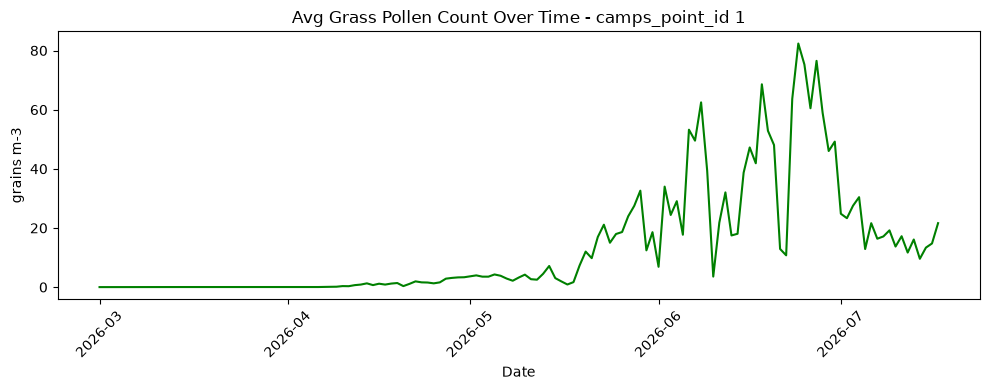

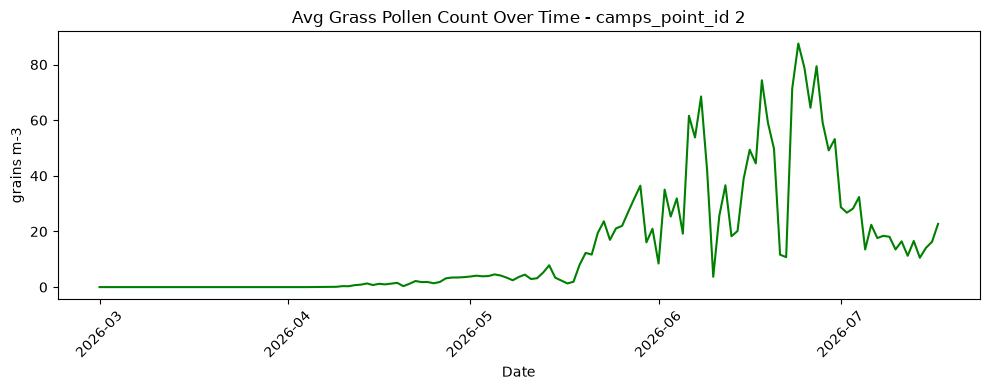

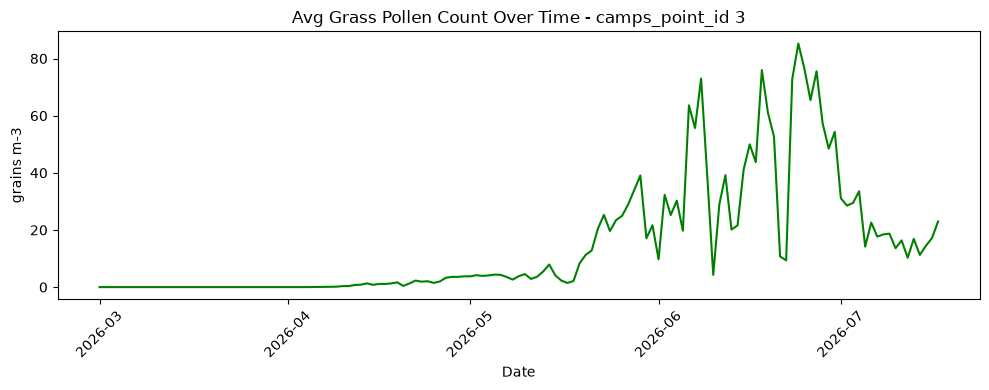

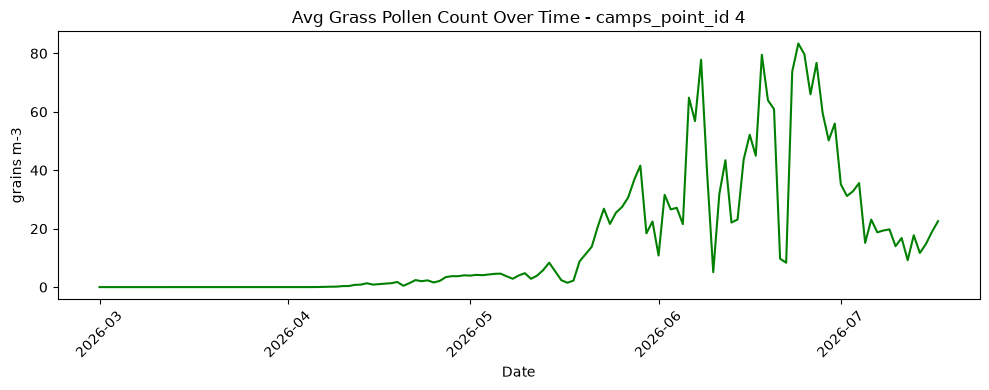

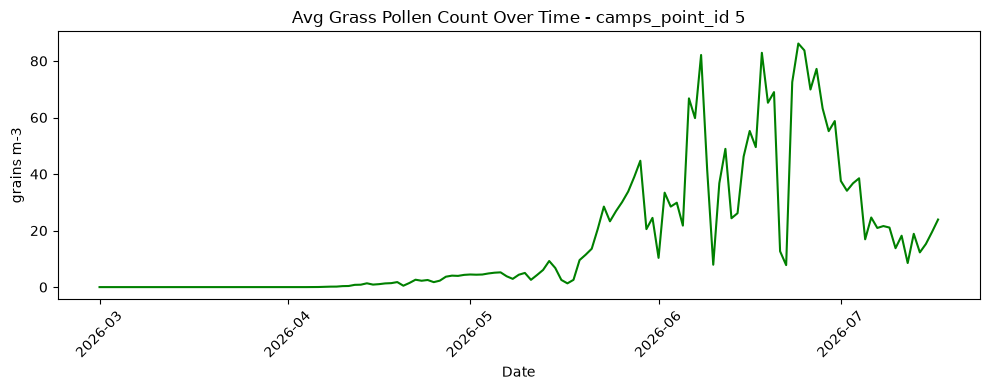

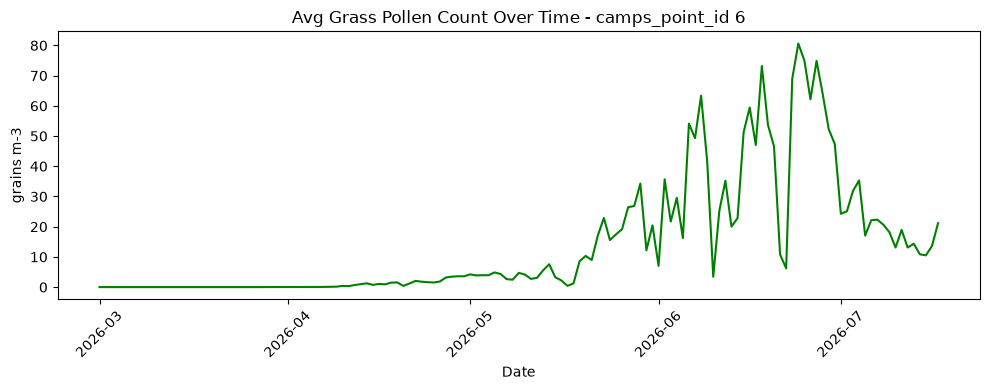

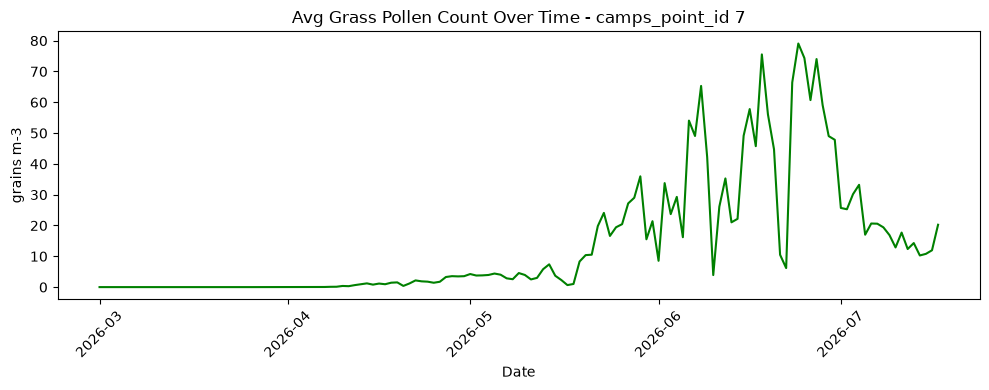

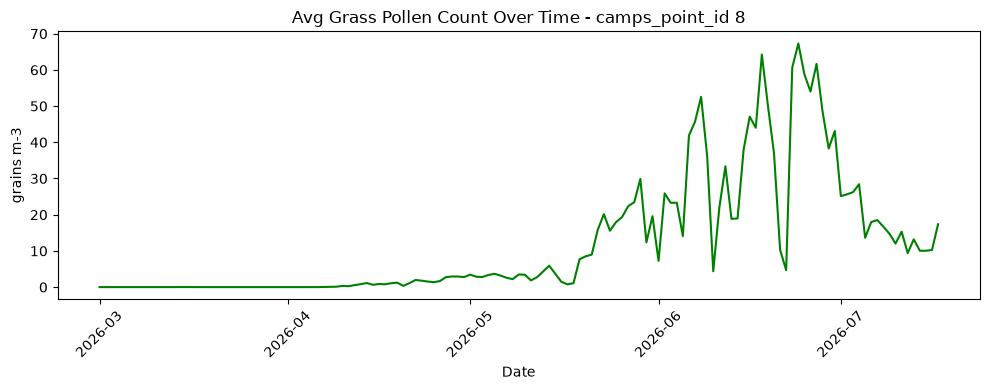

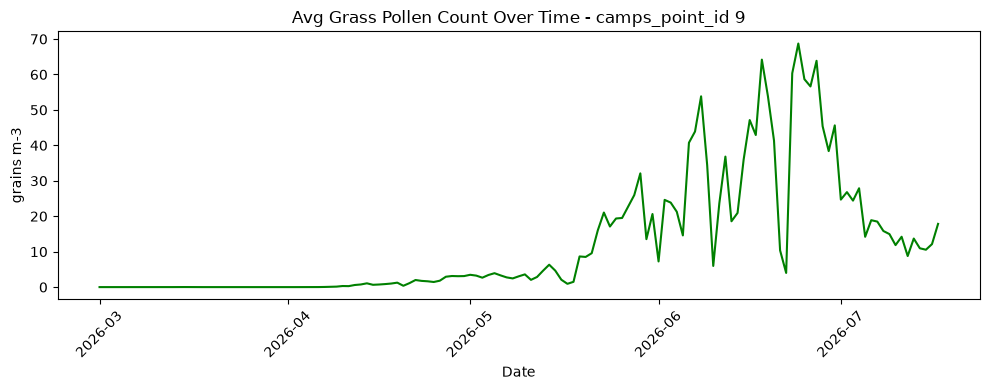

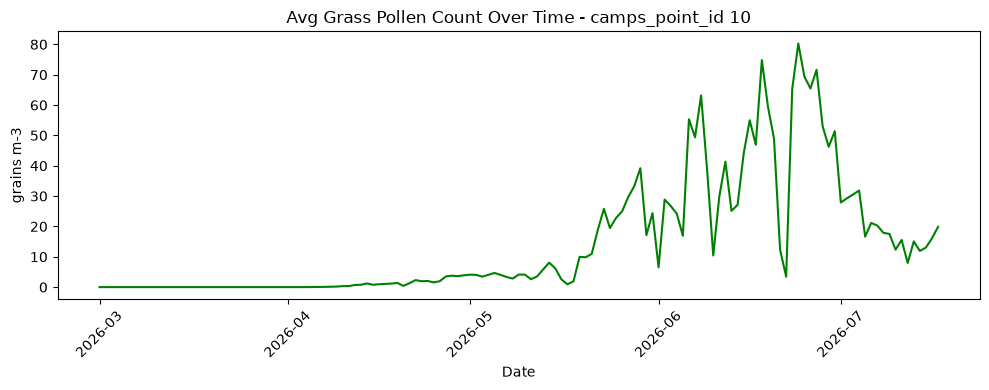

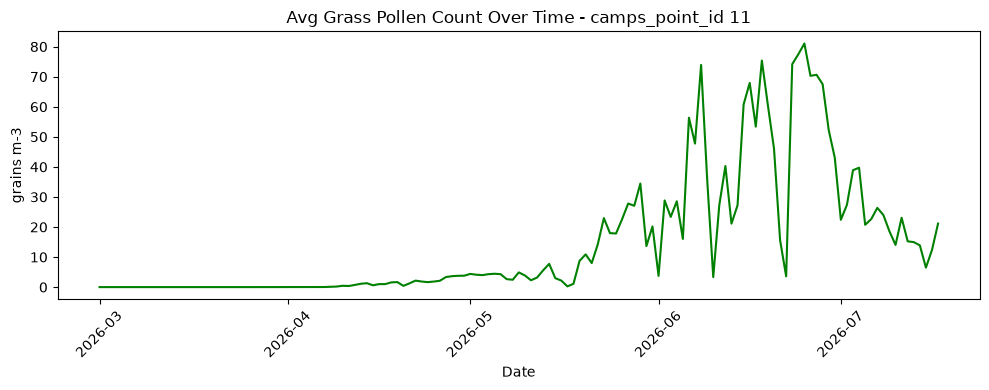

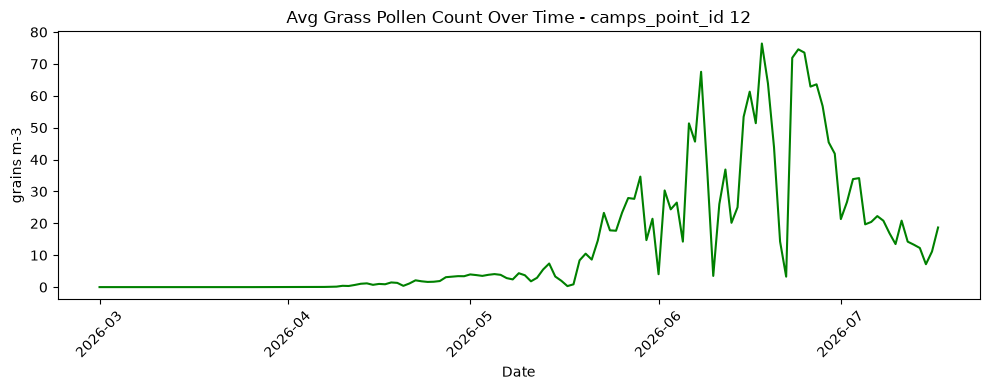

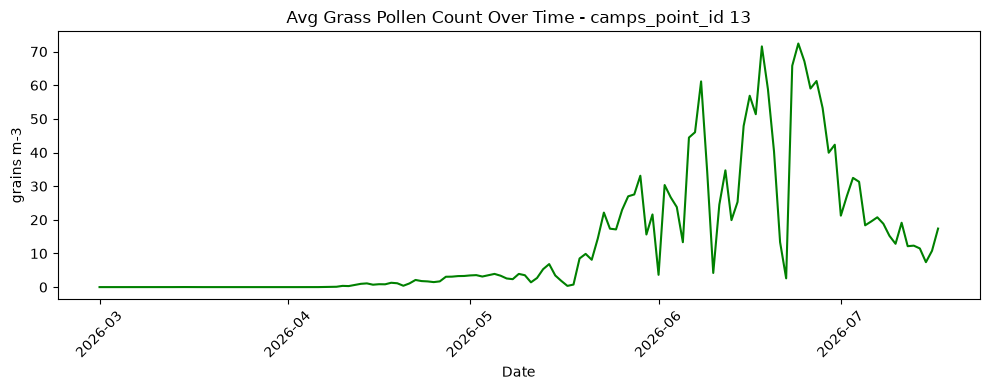

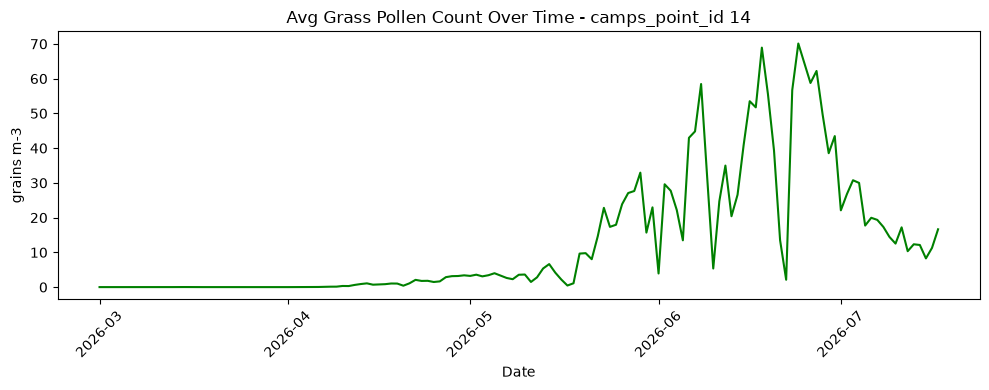

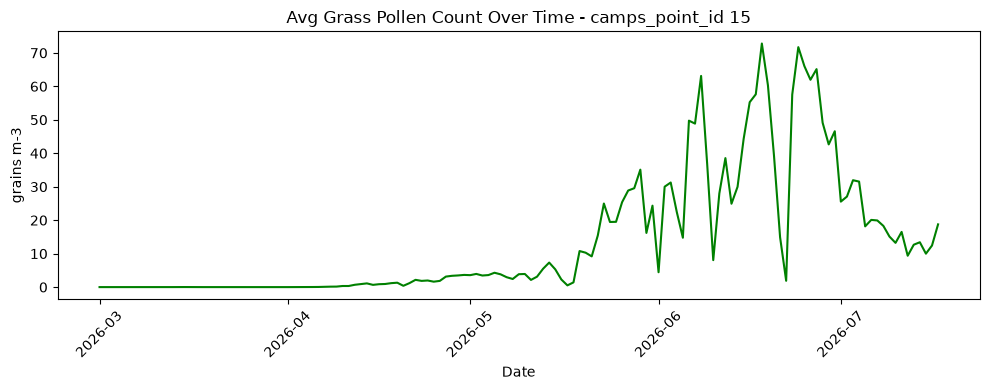

In [91]:
%matplotlib inline

site_ids = sorted(pd.to_numeric(df['camps_point_id'], errors='coerce').dropna().astype(int).unique())

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.figure(figsize=(10, 4))
    plt.plot(site_series.index, site_series.values, color='g')
    plt.title(f"Avg Grass Pollen Count Over Time - camps_point_id {site_id}")
    plt.xlabel("Date")
    plt.xticks(rotation=45)
    plt.ylabel("grains m-3")
    plt.tight_layout()
    plt.show()

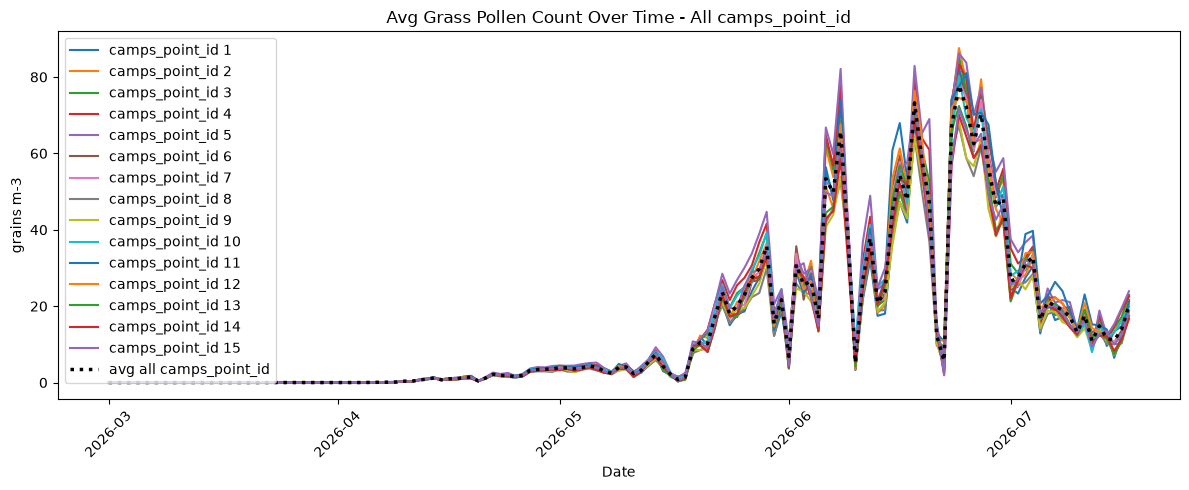

In [92]:
%matplotlib inline

plt.figure(figsize=(12, 5))

overall_avg = (
    df_grouped.groupby(level='fdate')['grass_pollen']
    .mean()
    .sort_index()
)

for site_id in site_ids:
    site_series = (
        df_grouped.xs(site_id, level='camps_point_id')['grass_pollen']
        .sort_index()
    )
    plt.plot(
        site_series.index,
        site_series.values,
        label=f'camps_point_id {site_id}',
        zorder=1
    )

plt.plot(
    overall_avg.index,
    overall_avg.values,
    label='avg all camps_point_id',
    linewidth=2.5,
    color='black',
    linestyle=':',
    zorder=2
)

plt.title('Avg Grass Pollen Count Over Time - All camps_point_id')
plt.xlabel('Date')
plt.xticks(rotation=45)
plt.ylabel('grains m-3')
plt.legend(loc='upper left', bbox_to_anchor=(0.0, 1.0))
plt.tight_layout()
plt.show()

In [93]:
df_grouped_time = (
    df.groupby(['fdate', 'ftime'], as_index=False)[
        ['alder_pollen', 'birch_pollen', 'grass_pollen', 'mugwort_pollen', 'olive_pollen', 'ragweed_pollen', 'pollen_total']
    ].mean()
)
df_grouped_time.tail(10)


,fdate,ftime,alder_pollen,birch_pollen,grass_pollen,mugwort_pollen,olive_pollen,ragweed_pollen,pollen_total
3326,2026-07-17,14:00:00,0.000,0.000,20.917,0.836,0.000,0.000,21.753
3327,2026-07-17,15:00:00,0.000,0.000,21.068,0.791,0.000,0.000,21.860
3328,2026-07-17,16:00:00,0.000,0.000,20.539,0.804,0.000,0.000,21.343
3329,2026-07-17,17:00:00,0.000,0.000,19.287,0.945,0.000,0.000,20.232
3330,2026-07-17,18:00:00,0.000,0.000,19.904,1.113,0.000,0.000,21.018
3331,2026-07-17,19:00:00,0.000,0.000,23.097,1.488,0.000,0.000,24.586
3332,2026-07-17,20:00:00,0.000,0.000,24.168,1.568,0.000,0.000,25.736
3333,2026-07-17,21:00:00,0.000,0.000,20.239,1.626,0.000,0.000,21.866
3334,2026-07-17,22:00:00,0.000,0.000,15.951,1.420,0.000,0.000,17.371
3335,2026-07-17,23:00:00,0.000,0.000,13.942,1.267,0.000,0.000,15.210


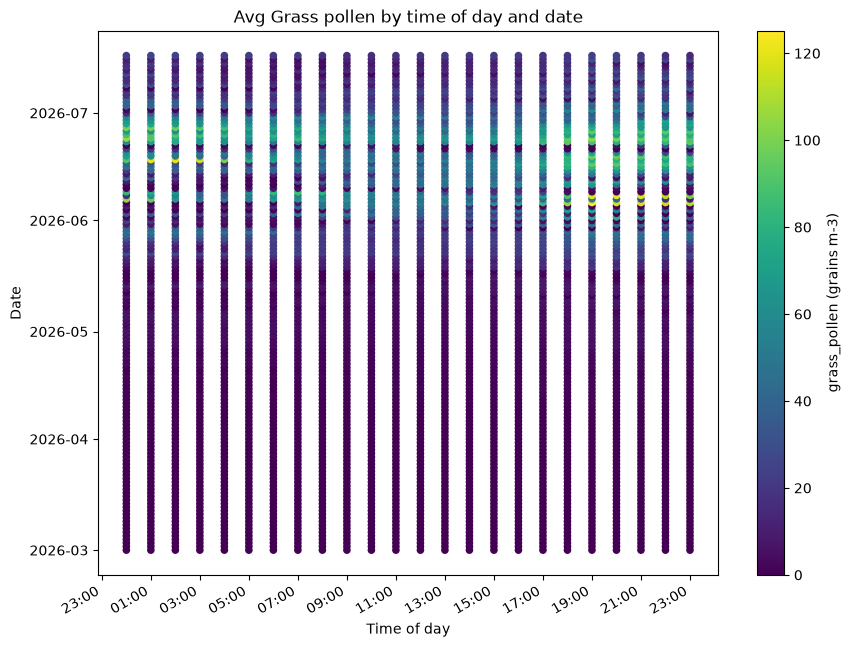

In [94]:
# Scatter plot: x = ftime (time of day), y = fdate (date), color = grass_pollen

ftimes = pd.to_datetime(df_grouped_time['ftime'].astype(str), format='%H:%M:%S', errors='coerce')
fdates = df_grouped_time['fdate']

plt.figure(figsize=(10, 8))
sc = plt.scatter(ftimes, fdates, c=df_grouped_time['grass_pollen'], cmap='viridis', s=20)
plt.colorbar(sc, label='grass_pollen (grains m-3)')
plt.xlabel('Time of day')
plt.ylabel('Date')
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=2))
plt.gcf().autofmt_xdate()
plt.title(f'Avg Grass pollen by time of day and date')
plt.show()


In [95]:
engine_render = create_engine(get_database_render_url(), pool_pre_ping=True)
df_synop = pd.read_sql(
    """SELECT * FROM public.synop_data
    ORDER BY date DESC, measurement_hour ASC """,
    engine_render
)

df_synop.head()

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,12566,2026-07-17,0,2026-07-17 01:00:39.397094,2026-07-17 01:00:39.394141,Kraków,16.600,2.000,250,93.100,2.100,1018.600
1,12566,2026-07-17,1,2026-07-17 02:00:51.445949,2026-07-17 02:00:51.443513,Kraków,16.000,1.000,30,94.900,2.100,1018.300
2,12566,2026-07-17,2,2026-07-17 03:00:45.648703,2026-07-17 03:00:45.646619,Kraków,16.100,1.000,250,96.800,2.100,1017.800
3,12566,2026-07-17,3,2026-07-17 04:00:31.445237,2026-07-17 04:00:31.440915,Kraków,15.700,0.000,0,96.200,2.100,1017.600
4,12566,2026-07-17,4,2026-07-17 05:00:34.380318,2026-07-17 05:00:34.377435,Kraków,16.900,1.000,290,85.500,2.100,1017.100


In [96]:
df_synop.dtypes

station_id                    int64
date                         object
measurement_hour              int64
date_add             datetime64[us]
date_update          datetime64[us]
station_name                    str
temperature                 float64
wind_speed                  float64
wind_direction                int64
relative_humidity           float64
rainfall_sum                float64
pressure                    float64
dtype: object

In [97]:
df_synop['date'] = pd.to_datetime(df_synop['date'], format='%Y-%m-%d')
df_synop['measurement_hour_dt'] = df_synop['date'] + pd.to_timedelta(df_synop['measurement_hour'], unit='h')
df_synop['measurement_hour'] = df_synop['measurement_hour_dt'].dt.time

df_synop['date_N_h_ahead'] = df_synop['measurement_hour_dt'] + pd.Timedelta(hours=12)

In [98]:
df_synop.head(5)

,station_id,date,measurement_hour,date_add,date_update,station_name,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,measurement_hour_dt,date_N_h_ahead
0,12566,2026-07-17,00:00:00,2026-07-17 01:00:39.397094,2026-07-17 01:00:39.394141,Kraków,16.600,2.000,250,93.100,2.100,1018.600,2026-07-17 00:00:00,2026-07-17 12:00:00
1,12566,2026-07-17,01:00:00,2026-07-17 02:00:51.445949,2026-07-17 02:00:51.443513,Kraków,16.000,1.000,30,94.900,2.100,1018.300,2026-07-17 01:00:00,2026-07-17 13:00:00
2,12566,2026-07-17,02:00:00,2026-07-17 03:00:45.648703,2026-07-17 03:00:45.646619,Kraków,16.100,1.000,250,96.800,2.100,1017.800,2026-07-17 02:00:00,2026-07-17 14:00:00
3,12566,2026-07-17,03:00:00,2026-07-17 04:00:31.445237,2026-07-17 04:00:31.440915,Kraków,15.700,0.000,0,96.200,2.100,1017.600,2026-07-17 03:00:00,2026-07-17 15:00:00
4,12566,2026-07-17,04:00:00,2026-07-17 05:00:34.380318,2026-07-17 05:00:34.377435,Kraków,16.900,1.000,290,85.500,2.100,1017.100,2026-07-17 04:00:00,2026-07-17 16:00:00


In [99]:
df_synop_filtered = df_synop[['date', 'date_N_h_ahead', 'measurement_hour', 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].copy()
df_synop_filtered.head()

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
0,2026-07-17,2026-07-17 12:00:00,00:00:00,16.600,2.000,250,93.100,2.100,1018.600
1,2026-07-17,2026-07-17 13:00:00,01:00:00,16.000,1.000,30,94.900,2.100,1018.300
2,2026-07-17,2026-07-17 14:00:00,02:00:00,16.100,1.000,250,96.800,2.100,1017.800
3,2026-07-17,2026-07-17 15:00:00,03:00:00,15.700,0.000,0,96.200,2.100,1017.600
4,2026-07-17,2026-07-17 16:00:00,04:00:00,16.900,1.000,290,85.500,2.100,1017.100


In [100]:
df_synop_filtered['date_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.date.copy()
df_synop_filtered['time_date_ahead'] = df_synop_filtered['date_N_h_ahead'].dt.time.copy()
df_synop_filtered['date_date_ahead'] = pd.to_datetime(df_synop_filtered['date_date_ahead'], format='%Y-%m-%d')
df_synop_filtered.head(24)

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead
0,2026-07-17,2026-07-17 12:00:00,00:00:00,16.600,2.000,250,93.100,2.100,1018.600,2026-07-17,12:00:00
1,2026-07-17,2026-07-17 13:00:00,01:00:00,16.000,1.000,30,94.900,2.100,1018.300,2026-07-17,13:00:00
2,2026-07-17,2026-07-17 14:00:00,02:00:00,16.100,1.000,250,96.800,2.100,1017.800,2026-07-17,14:00:00
3,2026-07-17,2026-07-17 15:00:00,03:00:00,15.700,0.000,0,96.200,2.100,1017.600,2026-07-17,15:00:00
4,2026-07-17,2026-07-17 16:00:00,04:00:00,16.900,1.000,290,85.500,2.100,1017.100,2026-07-17,16:00:00
5,2026-07-17,2026-07-17 17:00:00,05:00:00,19.600,1.000,40,78.800,2.100,1016.500,2026-07-17,17:00:00
6,2026-07-17,2026-07-17 18:00:00,06:00:00,21.900,1.000,50,69.500,0.000,1016.400,2026-07-17,18:00:00
7,2026-07-17,2026-07-17 19:00:00,07:00:00,24.400,2.000,60,63.000,0.000,1015.500,2026-07-17,19:00:00
8,2026-07-17,2026-07-17 20:00:00,08:00:00,26.300,2.000,60,52.900,0.000,1015.000,2026-07-17,20:00:00
9,2026-07-17,2026-07-17 21:00:00,09:00:00,27.800,2.000,130,47.000,0.000,1014.400,2026-07-17,21:00:00


In [101]:
df_synop_mean_by_date = df_synop_filtered.groupby('date', as_index=False)[[ 'temperature', 'wind_speed', 'wind_direction', 'relative_humidity', 'rainfall_sum', 'pressure']].mean()
df_synop_mean_by_date.tail()

,date,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure
122,2026-07-13,18.500,2.292,250.833,83.646,0.100,1019.292
123,2026-07-14,20.850,2.292,80.833,77.033,1.450,1018.271
124,2026-07-15,19.192,2.250,183.750,83.633,0.475,1019.346
125,2026-07-16,21.346,1.375,199.167,74.954,1.575,1019.550
126,2026-07-17,23.587,1.667,135.333,64.533,0.840,1015.267


In [102]:
df_merged = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date', 'ftime': 'measurement_hour'}),
    on=['date', 'measurement_hour'],
    how='left'
)
df_merged.head(24)

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
0,2026-07-17,2026-07-17 12:00:00,00:00:00,16.600,2.000,250,93.100,2.100,1018.600,2026-07-17,12:00:00,22.151
1,2026-07-17,2026-07-17 13:00:00,01:00:00,16.000,1.000,30,94.900,2.100,1018.300,2026-07-17,13:00:00,25.132
2,2026-07-17,2026-07-17 14:00:00,02:00:00,16.100,1.000,250,96.800,2.100,1017.800,2026-07-17,14:00:00,24.552
3,2026-07-17,2026-07-17 15:00:00,03:00:00,15.700,0.000,0,96.200,2.100,1017.600,2026-07-17,15:00:00,22.875
4,2026-07-17,2026-07-17 16:00:00,04:00:00,16.900,1.000,290,85.500,2.100,1017.100,2026-07-17,16:00:00,21.610
5,2026-07-17,2026-07-17 17:00:00,05:00:00,19.600,1.000,40,78.800,2.100,1016.500,2026-07-17,17:00:00,22.301
6,2026-07-17,2026-07-17 18:00:00,06:00:00,21.900,1.000,50,69.500,0.000,1016.400,2026-07-17,18:00:00,19.846
7,2026-07-17,2026-07-17 19:00:00,07:00:00,24.400,2.000,60,63.000,0.000,1015.500,2026-07-17,19:00:00,20.215
8,2026-07-17,2026-07-17 20:00:00,08:00:00,26.300,2.000,60,52.900,0.000,1015.000,2026-07-17,20:00:00,17.488
9,2026-07-17,2026-07-17 21:00:00,09:00:00,27.800,2.000,130,47.000,0.000,1014.400,2026-07-17,21:00:00,16.077


In [103]:
df_merged_mean_temperature_by_date = df_merged.merge(
    df_synop_mean_by_date[['date', 'temperature']].rename(columns={'temperature': 'avg_day_temperature'}),
    on=['date'],
    how='left'
)
df_merged_mean_temperature_by_date.head()

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
0,2026-07-17,2026-07-17 12:00:00,00:00:00,16.600,2.000,250,93.100,2.100,1018.600,2026-07-17,12:00:00,22.151,23.587
1,2026-07-17,2026-07-17 13:00:00,01:00:00,16.000,1.000,30,94.900,2.100,1018.300,2026-07-17,13:00:00,25.132,23.587
2,2026-07-17,2026-07-17 14:00:00,02:00:00,16.100,1.000,250,96.800,2.100,1017.800,2026-07-17,14:00:00,24.552,23.587
3,2026-07-17,2026-07-17 15:00:00,03:00:00,15.700,0.000,0,96.200,2.100,1017.600,2026-07-17,15:00:00,22.875,23.587
4,2026-07-17,2026-07-17 16:00:00,04:00:00,16.900,1.000,290,85.500,2.100,1017.100,2026-07-17,16:00:00,21.610,23.587


In [104]:
df_merged_date_ahead = df_synop_filtered.merge(
    df_grouped_time[['fdate', 'ftime', 'grass_pollen']].rename(columns={'fdate': 'date_date_ahead', 'ftime': 'time_date_ahead'}),
    on=['date_date_ahead', 'time_date_ahead'],
    how='left'
)
df_merged_date_ahead.tail(50)

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen
2950,2026-03-15,2026-03-15 22:00:00,10:00:00,17.500,1.000,90,31.500,0.000,1011.700,2026-03-15,22:00:00,0.005
2951,2026-03-15,2026-03-15 23:00:00,11:00:00,18.800,1.000,180,29.400,0.000,1011.600,2026-03-15,23:00:00,0.005
2952,2026-03-15,2026-03-16 00:00:00,12:00:00,18.100,3.000,60,28.600,0.000,1011.300,2026-03-16,00:00:00,0.006
2953,2026-03-15,2026-03-16 01:00:00,13:00:00,17.900,3.000,110,29.600,0.000,1011.300,2026-03-16,01:00:00,0.006
2954,2026-03-15,2026-03-16 02:00:00,14:00:00,17.000,3.000,60,31.600,0.000,1011.400,2026-03-16,02:00:00,0.006
2955,2026-03-15,2026-03-16 03:00:00,15:00:00,17.400,3.000,40,28.600,0.000,1011.300,2026-03-16,03:00:00,0.007
2956,2026-03-15,2026-03-16 04:00:00,16:00:00,16.000,3.000,10,32.500,0.000,1011.800,2026-03-16,04:00:00,0.008
2957,2026-03-15,2026-03-16 05:00:00,17:00:00,13.800,4.000,330,45.600,0.000,1012.500,2026-03-16,05:00:00,0.009
2958,2026-03-15,2026-03-16 06:00:00,18:00:00,12.900,5.000,340,50.600,0.000,1013.100,2026-03-16,06:00:00,0.011
2959,2026-03-15,2026-03-16 07:00:00,19:00:00,11.000,4.000,50,62.500,0.000,1014.000,2026-03-16,07:00:00,0.011


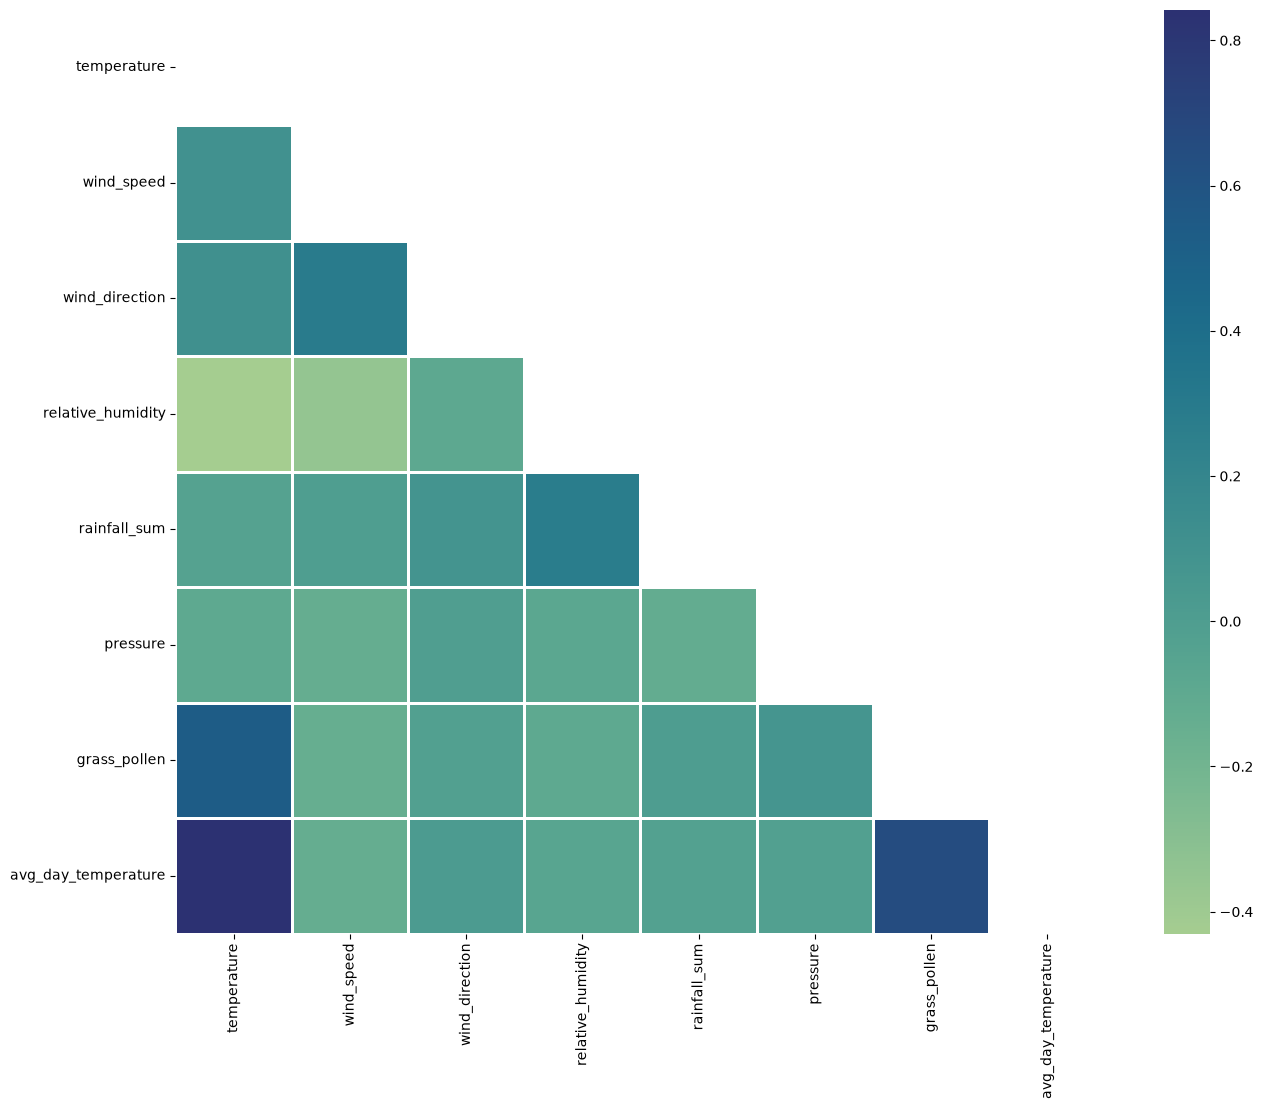

In [105]:
#triangular matrix
num_cols = df_merged_mean_temperature_by_date.select_dtypes(['int', 'float']).columns
corr_data = df_merged_mean_temperature_by_date[num_cols]

corr_coef = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef)
sns.heatmap(corr_coef,linewidth=.8, mask = matrix, cmap="crest");

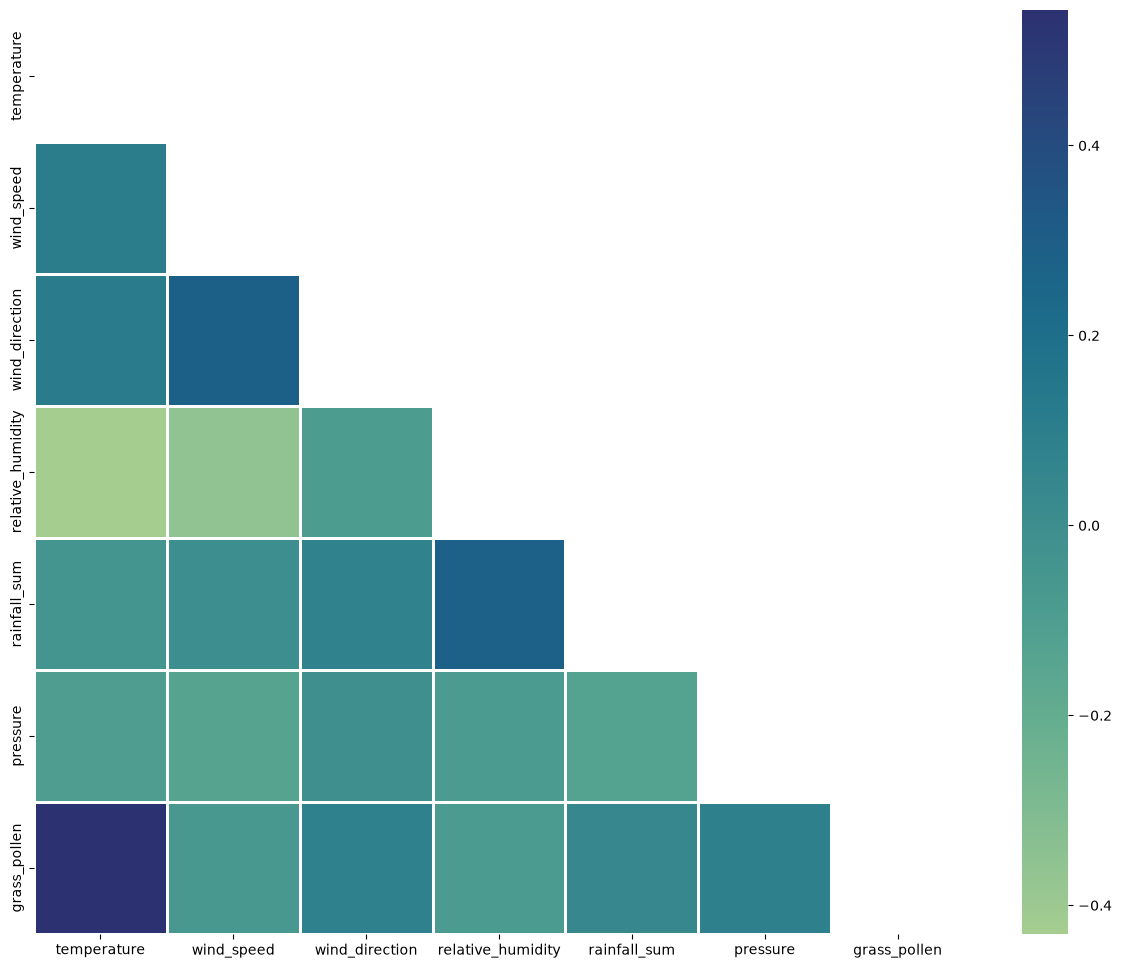

In [106]:
#triangular matrix date ahead
num_cols_date_ahead = df_merged_date_ahead.select_dtypes(['int', 'float']).columns
corr_data = df_merged_date_ahead[num_cols_date_ahead]

corr_coef_date_ahead = corr_data.corr()
plt.figure(figsize=(15, 12))
matrix = np.triu(corr_coef_date_ahead)
sns.heatmap(corr_coef_date_ahead,linewidth=.8, mask = matrix, cmap="crest");

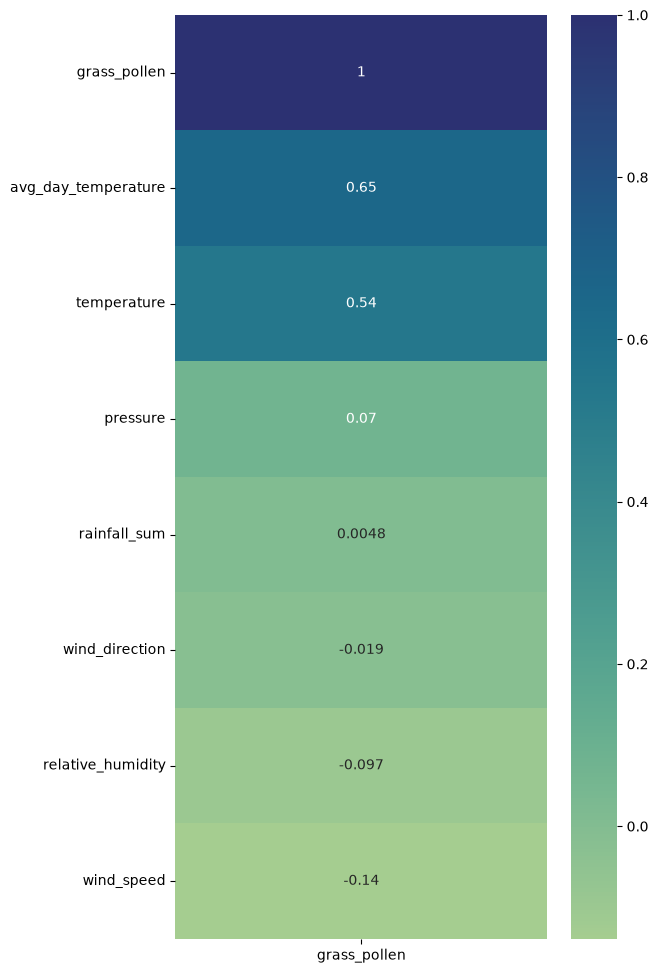

In [107]:
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);

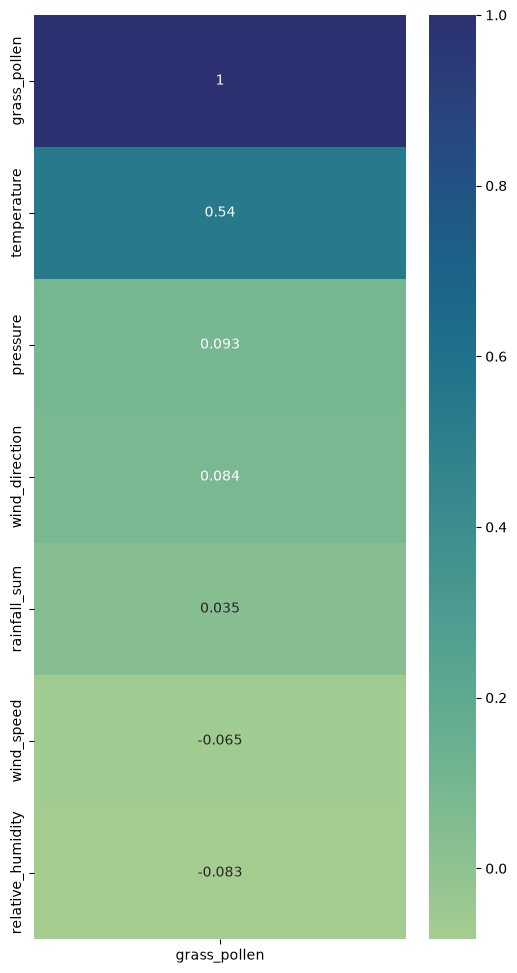

In [108]:
#date ahead
plt.figure(figsize=(6,12))
sns.heatmap(corr_coef_date_ahead[['grass_pollen']].sort_values(by=['grass_pollen'], ascending=False),
            cmap='crest',
            annot=True);


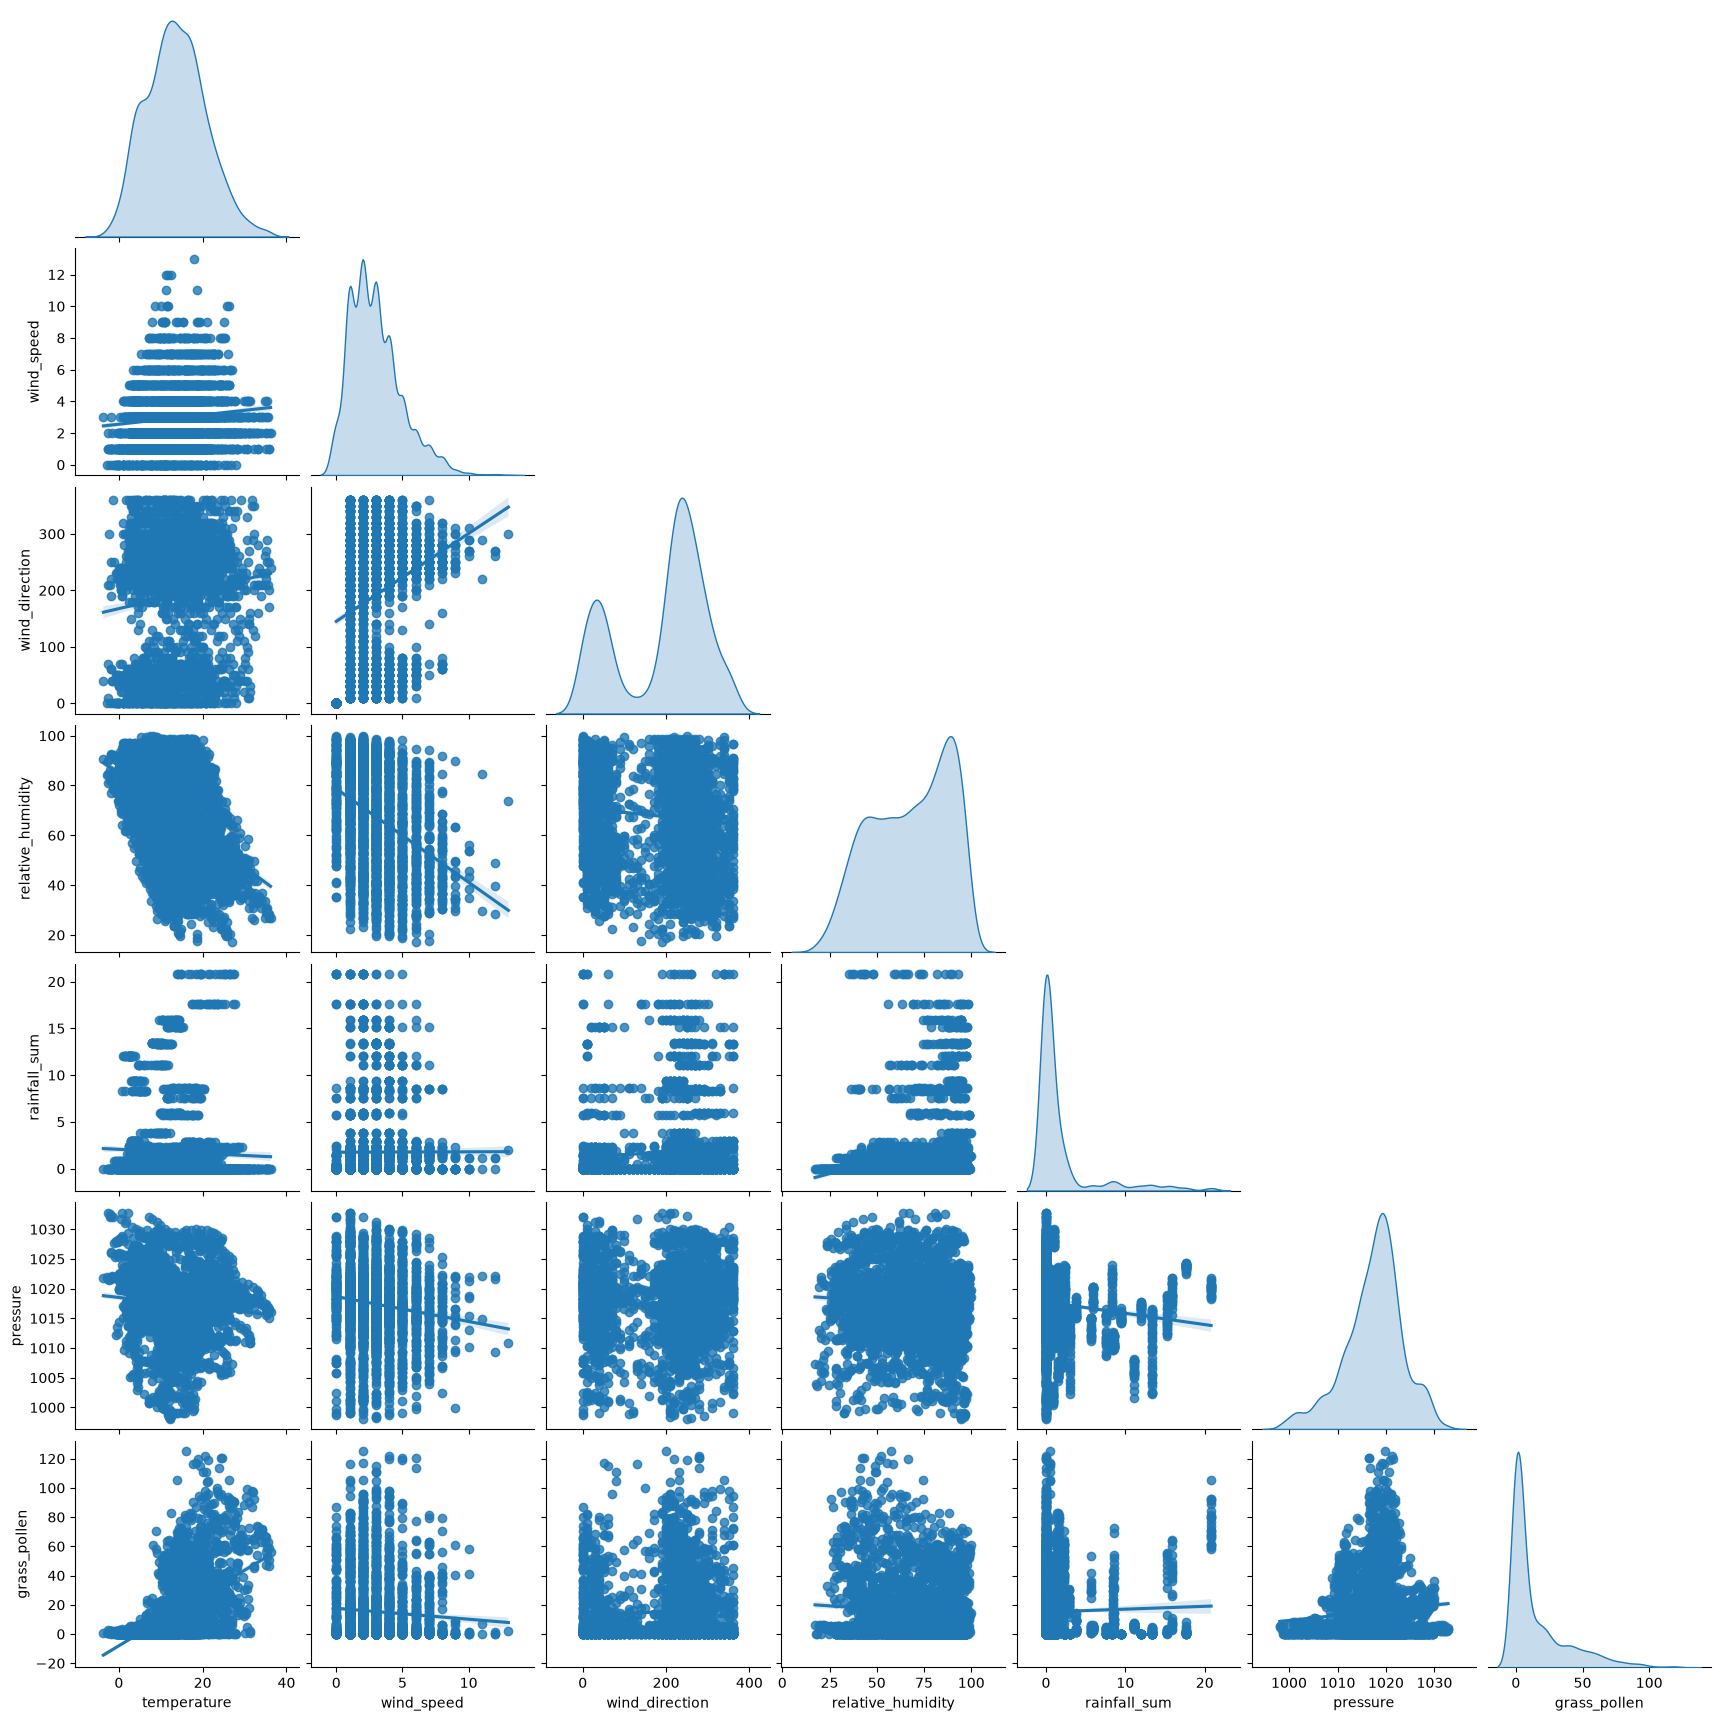

In [109]:
sns.pairplot(corr_data, corner=True, kind='reg', diag_kind='kde')

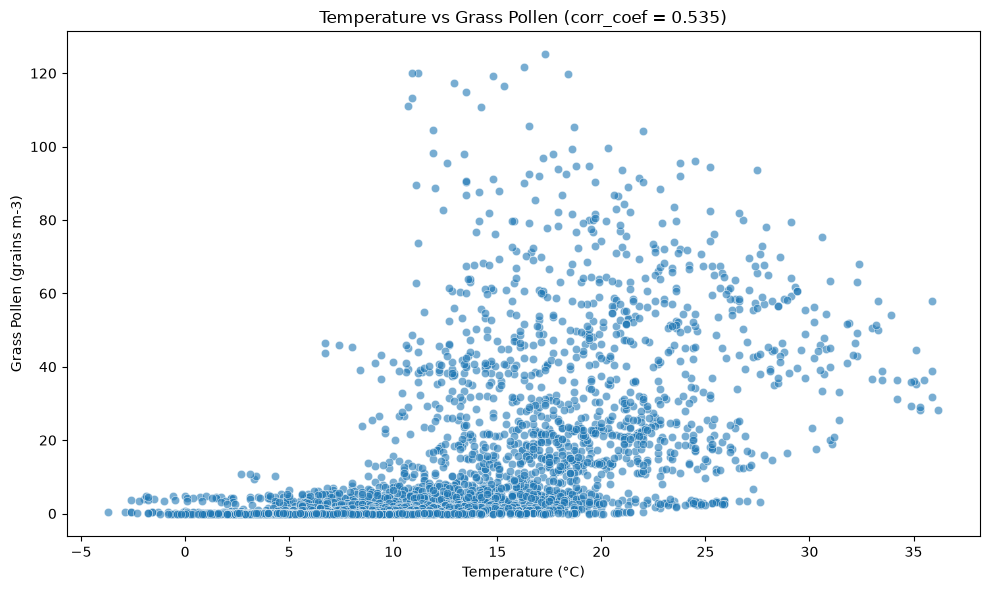

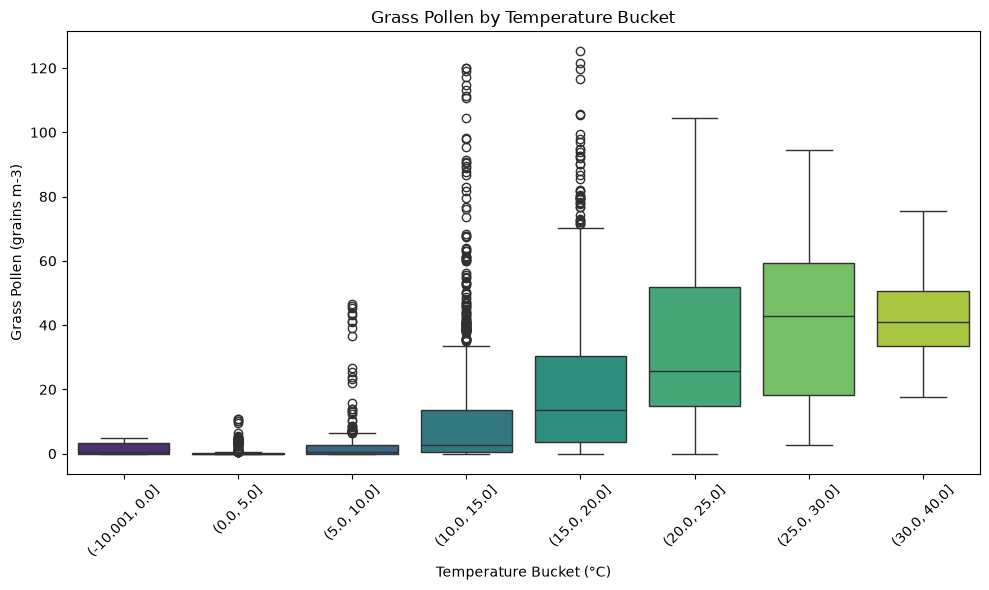

In [110]:
scatter_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=scatter_df, x='temperature', y='grass_pollen', alpha=0.6)
#sns.regplot(data=scatter_df, x='temperature', y='grass_pollen', scatter=False, color='black')
plt.title(f'Temperature vs Grass Pollen (corr_coef = {scatter_df[["temperature", "grass_pollen"]].corr().iloc[0, 1]:.3f})')
plt.xlabel('Temperature (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.tight_layout()
plt.show()

bucket_df = df_merged.dropna(subset=['temperature', 'grass_pollen']).copy()
bucket_df['temperature_bucket'] = pd.cut(
    bucket_df['temperature'],
    bins=[-10, 0, 5, 10, 15, 20, 25, 30, 40],
    right=True,
    include_lowest=True
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=bucket_df, x='temperature_bucket', y='grass_pollen', hue='temperature_bucket', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Temperature Bucket')
plt.xlabel('Temperature Bucket (°C)')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

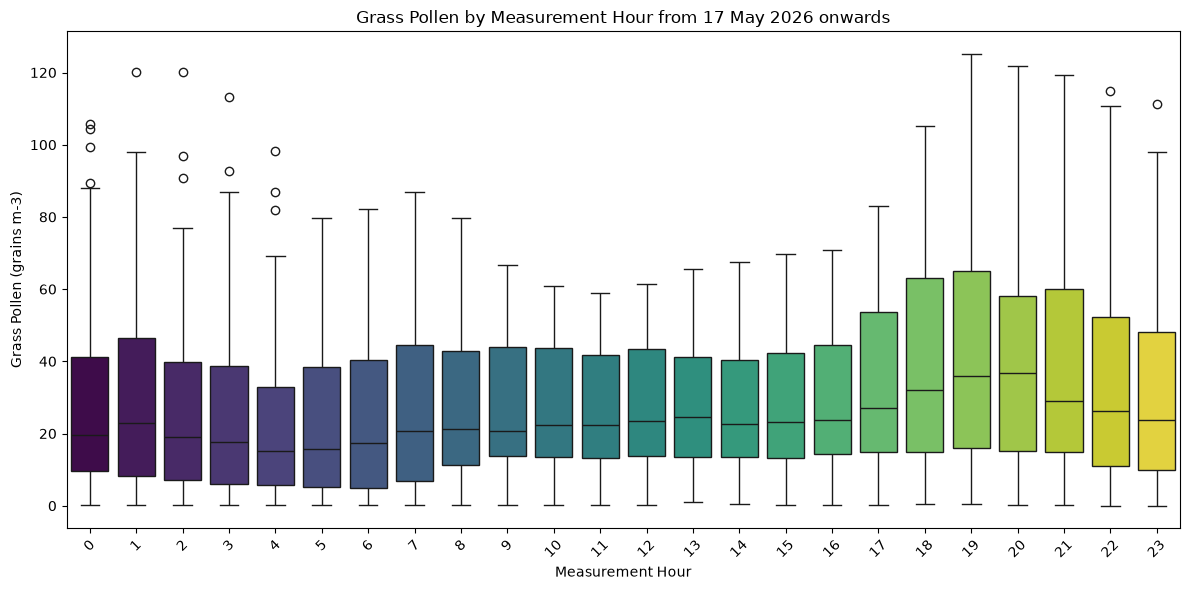

In [111]:
df_merged_from_date = df_merged[df_merged['date'] >= '2026-05-17'].copy()
hourly_df = df_merged_from_date.dropna(subset=['measurement_hour', 'grass_pollen']).copy()
hourly_df['measurement_hour'] = hourly_df['measurement_hour'].apply(lambda h: h.hour)

plt.figure(figsize=(12, 6))
sns.boxplot(data=hourly_df, x='measurement_hour', y='grass_pollen', hue='measurement_hour', dodge=False, legend=False, palette='viridis')
plt.title('Grass Pollen by Measurement Hour from 17 May 2026 onwards')
plt.xlabel('Measurement Hour')
plt.ylabel('Grass Pollen (grains m-3)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [112]:
df_merged_from_date_range_1 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-05-28') & (df_merged_mean_temperature_by_date['date'] < '2026-06-05')].copy()
plot_df_1 = df_merged_from_date_range_1.sort_values(['date', 'measurement_hour'])
plot_df_1.head(60)

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
1166,2026-05-28,2026-05-28 12:00:00,00:00:00,12.300,3.000,310,46.600,0.000,1020.100,2026-05-28,12:00:00,40.535,14.425
1167,2026-05-28,2026-05-28 13:00:00,01:00:00,11.700,3.000,310,48.500,0.000,1020.100,2026-05-28,13:00:00,40.131,14.425
1168,2026-05-28,2026-05-28 14:00:00,02:00:00,8.400,2.000,270,64.700,0.000,1020.600,2026-05-28,14:00:00,39.185,14.425
1169,2026-05-28,2026-05-28 15:00:00,03:00:00,9.400,1.000,230,61.700,0.000,1020.800,2026-05-28,15:00:00,36.672,14.425
1170,2026-05-28,2026-05-28 16:00:00,04:00:00,10.400,3.000,260,60.700,0.000,1021.200,2026-05-28,16:00:00,32.948,14.425
1171,2026-05-28,2026-05-28 17:00:00,05:00:00,12.200,4.000,290,54.500,0.000,1021.400,2026-05-28,17:00:00,28.696,14.425
1172,2026-05-28,2026-05-28 18:00:00,06:00:00,13.400,4.000,280,54.400,0.000,1021.700,2026-05-28,18:00:00,24.191,14.425
1173,2026-05-28,2026-05-28 19:00:00,07:00:00,14.300,5.000,270,47.400,0.000,1021.800,2026-05-28,19:00:00,21.653,14.425
1174,2026-05-28,2026-05-28 20:00:00,08:00:00,15.600,5.000,290,39.400,0.000,1021.700,2026-05-28,20:00:00,19.689,14.425
1175,2026-05-28,2026-05-28 21:00:00,09:00:00,16.700,5.000,300,39.400,0.000,1021.700,2026-05-28,21:00:00,18.272,14.425


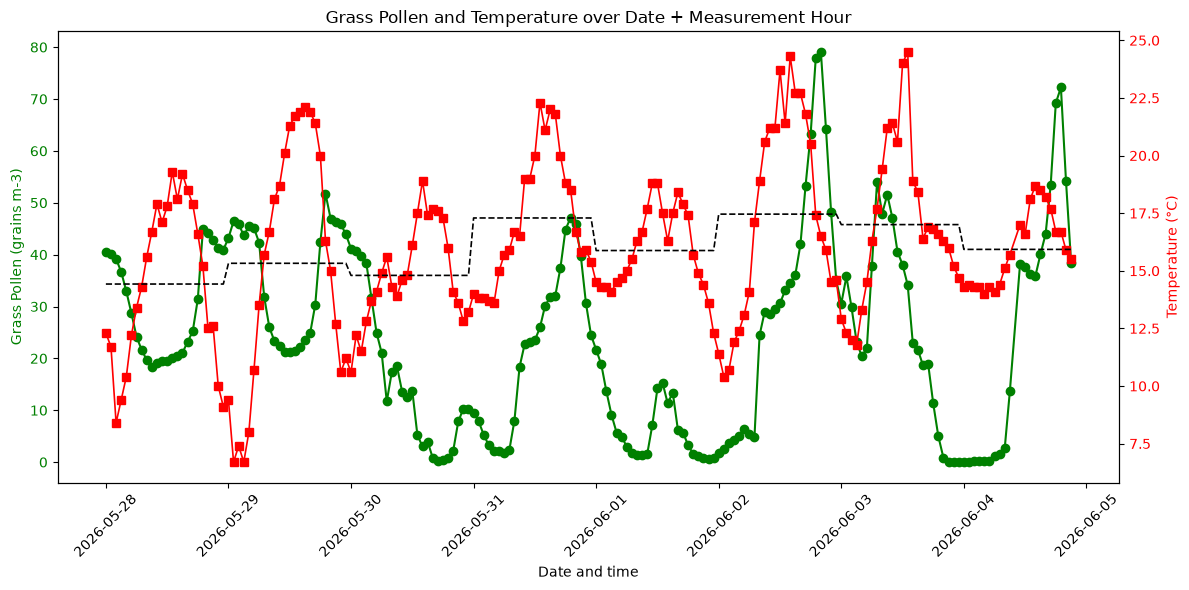

In [113]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
data_3 = plot_df_1['avg_day_temperature']

x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

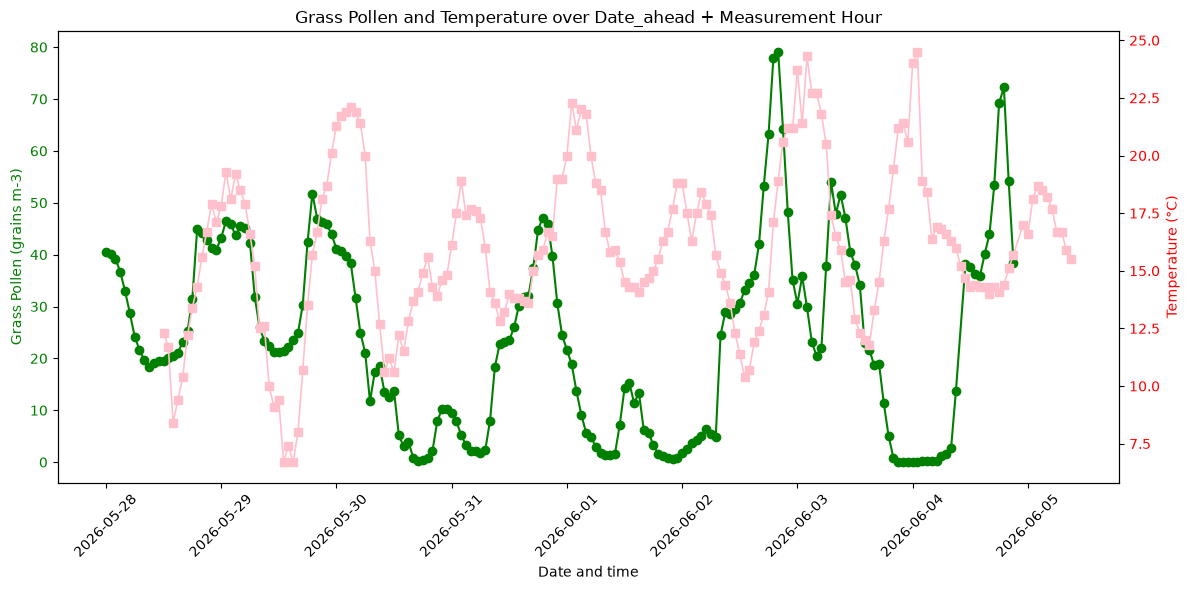

In [114]:
data_1 = plot_df_1['grass_pollen']
data_2 = plot_df_1['temperature']
x = pd.to_datetime(
    plot_df_1['date'].astype(str)
    + ' '    
    + plot_df_1['measurement_hour'].astype(str)
)
x_ahead = plot_df_1['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [115]:
df_merged_from_date_range_2 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-07-02') & (df_merged_mean_temperature_by_date['date'] < '2026-07-09')].copy()
plot_df_2 = df_merged_from_date_range_2.sort_values(['date', 'measurement_hour'])
plot_df_2[50:100]

,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
308,2026-07-04,2026-07-05 11:00:00,23:00:00,12.200,2.000,220,71.700,0.100,1019.200,2026-07-05,11:00:00,45.742,15.800
279,2026-07-05,2026-07-05 12:00:00,00:00:00,11.400,2.000,250,76.700,0.100,1019.000,2026-07-05,12:00:00,38.463,15.487
280,2026-07-05,2026-07-05 13:00:00,01:00:00,11.200,2.000,250,82.700,0.100,1018.500,2026-07-05,13:00:00,35.792,15.487
281,2026-07-05,2026-07-05 14:00:00,02:00:00,12.800,3.000,230,77.900,0.100,1017.900,2026-07-05,14:00:00,33.288,15.487
282,2026-07-05,2026-07-05 15:00:00,03:00:00,13.200,3.000,230,79.600,0.100,1017.700,2026-07-05,15:00:00,26.512,15.487
283,2026-07-05,2026-07-05 16:00:00,04:00:00,12.600,3.000,220,94.200,0.100,1017.300,2026-07-05,16:00:00,20.931,15.487
284,2026-07-05,2026-07-05 17:00:00,05:00:00,13.200,3.000,210,94.200,0.100,1016.900,2026-07-05,17:00:00,18.963,15.487
285,2026-07-05,2026-07-05 18:00:00,06:00:00,13.200,4.000,230,94.200,0.900,1016.600,2026-07-05,18:00:00,15.270,15.487
286,2026-07-05,2026-07-05 19:00:00,07:00:00,13.600,4.000,220,96.100,0.900,1016.200,2026-07-05,19:00:00,14.845,15.487
287,2026-07-05,2026-07-05 20:00:00,08:00:00,16.400,7.000,240,88.900,0.900,1015.600,2026-07-05,20:00:00,15.682,15.487


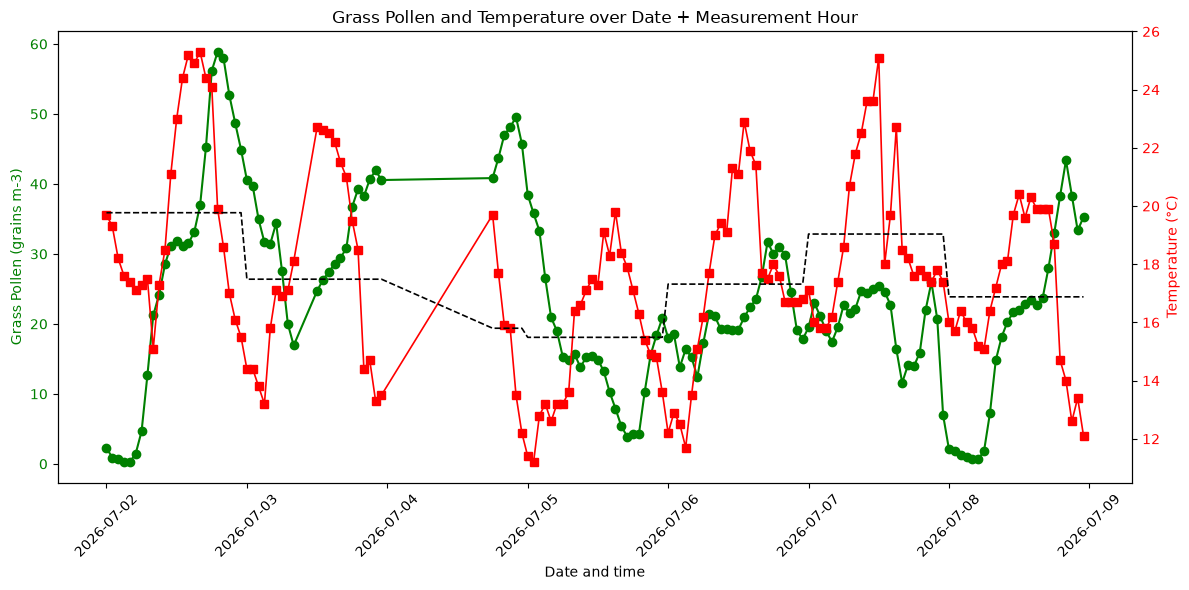

In [116]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
data_3 = plot_df_2['avg_day_temperature']

x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

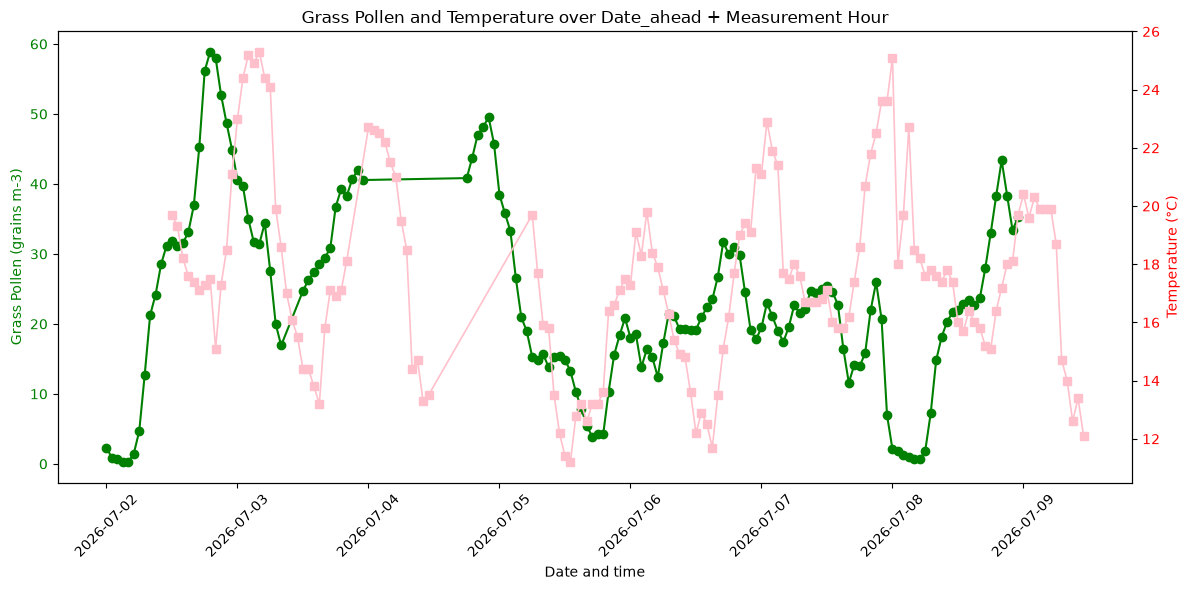

In [117]:
data_1 = plot_df_2['grass_pollen']
data_2 = plot_df_2['temperature']
x = pd.to_datetime(
    plot_df_2['date'].astype(str)
    + ' '    
    + plot_df_2['measurement_hour'].astype(str)
)

x_ahead = plot_df_2['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()

In [118]:
df_merged_from_date_range_3 = df_merged_mean_temperature_by_date[(df_merged_mean_temperature_by_date['date'] >= '2026-06-28') & (df_merged_mean_temperature_by_date['date'] < '2026-07-02')].copy()
plot_df_3 = df_merged_from_date_range_3.sort_values(['date', 'measurement_hour'])
plot_df_3[20:70]


,date,date_N_h_ahead,measurement_hour,temperature,wind_speed,wind_direction,relative_humidity,rainfall_sum,pressure,date_date_ahead,time_date_ahead,grass_pollen,avg_day_temperature
446,2026-06-28,2026-06-29 08:00:00,20:00:00,26.400,1.000,290,65.000,0.000,1017.800,2026-06-29,08:00:00,63.685,28.458
447,2026-06-28,2026-06-29 09:00:00,21:00:00,25.800,0.000,0,68.300,0.000,1018.200,2026-06-29,09:00:00,65.491,28.458
448,2026-06-28,2026-06-29 10:00:00,22:00:00,25.300,1.000,40,70.500,0.000,1018.400,2026-06-29,10:00:00,67.530,28.458
449,2026-06-28,2026-06-29 11:00:00,23:00:00,23.700,0.000,0,78.300,0.000,1018.300,2026-06-29,11:00:00,71.064,28.458
402,2026-06-29,2026-06-29 12:00:00,00:00:00,22.700,0.000,0,83.800,0.000,1018.200,2026-06-29,12:00:00,66.219,28.904
403,2026-06-29,2026-06-29 13:00:00,01:00:00,21.400,1.000,20,87.500,0.000,1018.200,2026-06-29,13:00:00,63.154,28.904
404,2026-06-29,2026-06-29 14:00:00,02:00:00,20.800,0.000,0,88.600,0.000,1018.200,2026-06-29,14:00:00,62.713,28.904
405,2026-06-29,2026-06-29 15:00:00,03:00:00,20.600,0.000,0,88.600,0.000,1018.300,2026-06-29,15:00:00,58.815,28.904
406,2026-06-29,2026-06-29 16:00:00,04:00:00,22.200,1.000,270,79.600,0.000,1018.300,2026-06-29,16:00:00,56.225,28.904
407,2026-06-29,2026-06-29 17:00:00,05:00:00,26.800,0.000,0,59.900,0.000,1017.900,2026-06-29,17:00:00,50.333,28.904


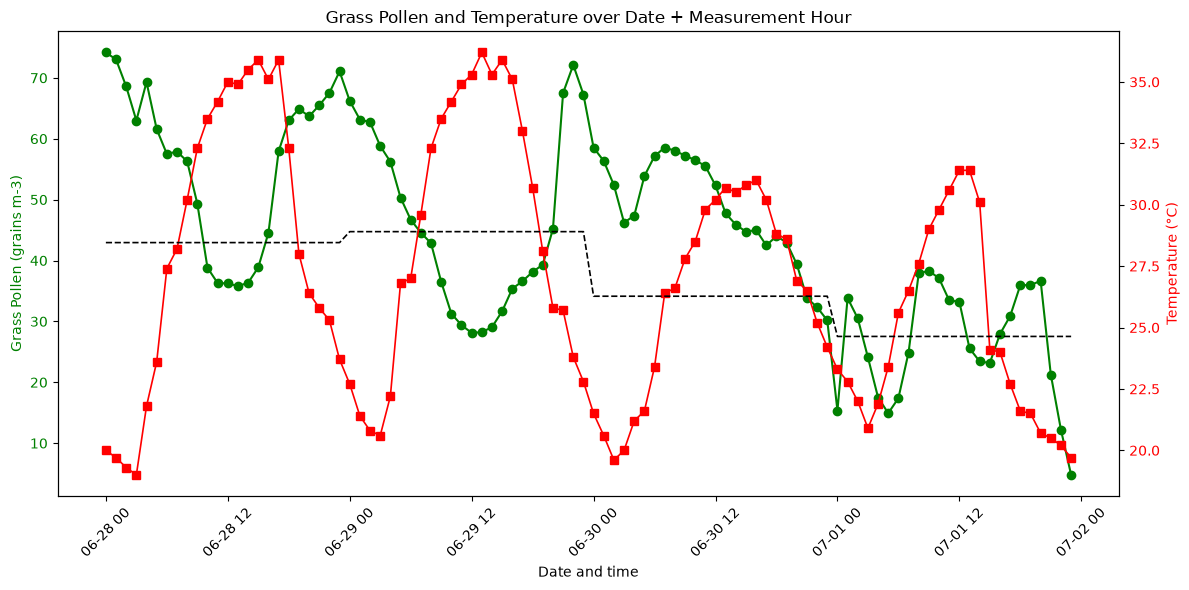

In [119]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
data_3 = plot_df_3['avg_day_temperature']

x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x, data_2, color='red', marker='s', linewidth=1.2)
ax2.plot(x, data_3, color='black', linewidth=1.2, linestyle='--', label='Avg Day Temperature')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date + Measurement Hour')
plt.tight_layout()
plt.show()

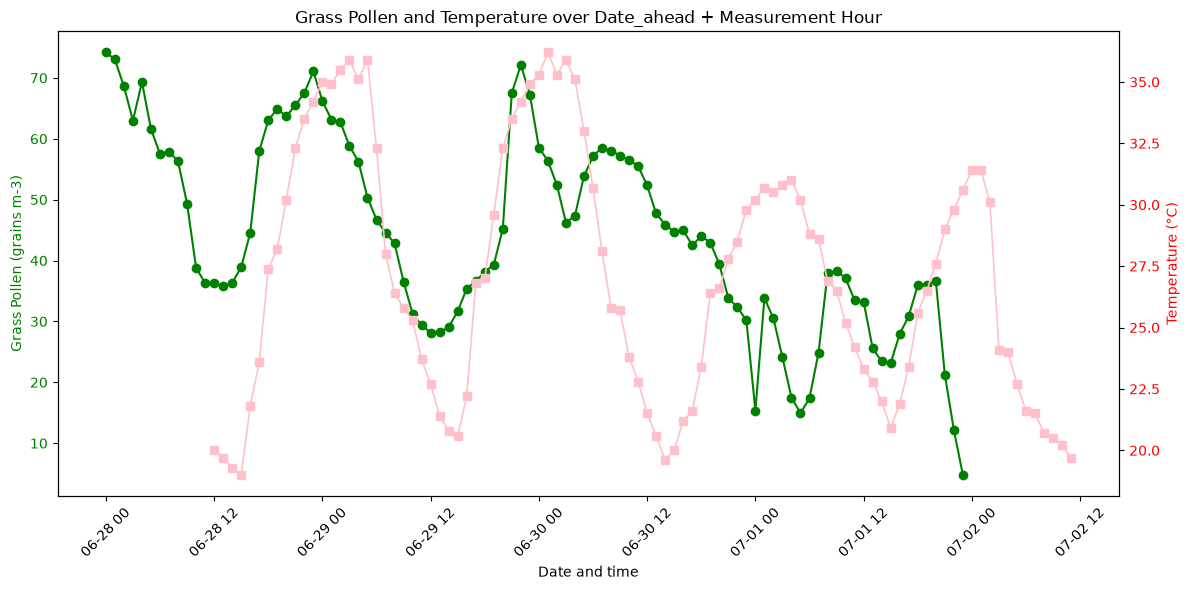

In [120]:
data_1 = plot_df_3['grass_pollen']
data_2 = plot_df_3['temperature']
x = pd.to_datetime(
    plot_df_3['date'].astype(str)
    + ' '    
    + plot_df_3['measurement_hour'].astype(str)
)

x_ahead = plot_df_3['date_N_h_ahead']

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.set_xlabel('Date and time')
ax1.set_ylabel('Grass Pollen (grains m-3)', color='green')
ax1.plot(x, data_1, color='green', marker='o', linewidth=1.5)
ax1.tick_params(axis='y', labelcolor='green')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx()
ax2.set_ylabel('Temperature (°C)', color='red')
ax2.plot(x_ahead, data_2, color='pink', marker='s', linewidth=1.2)
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Grass Pollen and Temperature over Date_ahead + Measurement Hour')
plt.tight_layout()
plt.show()